<a href="https://colab.research.google.com/github/vishnu-17o7/SEM-8/blob/main/docs/simulate/quantum_virtual_machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2022 The Cirq Developers

In [14]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Quantum Virtual Machine

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://quantumai.google/cirq/simulate/quantum_virtual_machine"><img src="https://quantumai.google/site-assets/images/buttons/quantumai_logo_1x.png" />View on QuantumAI</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/quantumlib/Cirq/blob/main/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/colab_logo_1x.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/quantumlib/Cirq/blob/main/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/github_logo_1x.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/Cirq/docs/simulate/quantum_virtual_machine.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/download_icon_1x.png" />Download notebook</a>
  </td>
</table>

The quantum virtual machine is a virtual Google quantum processor that you can run circuits on by using the [virtual engine interface](./virtual_engine_interface.ipynb). Behind this interface, it uses simulation with noise data to mimic Google quantum hardware processors with high accuracy: In internal tests, the virtual and actual hardware are within experimental error of each other. Additionally, it supports internal use of the high-performance [qsim](/qsim) simulator, for fast execution of larger circuits. The QVM should be used as a preparation step before running on Google hardware, and as a substitute for Google hardware when it is not available.

If you just want to use the QVM for realistic noisy simulation, you can copy and build upon the [QVM Creation Template](./qvm_builder_code.ipynb), which provides a concise and portable way to instantiate an `Engine` class that you can realistically simulate circuit runs with. After doing so, skip forward to the [How to use a QVM](#how_to_use_a_qvm) section. If you're interested in how the QVM is prepared for use, continue on to the following section.

## Setup

In [15]:
# @title Install `cirq_google` and `qsimcirq`

try:
    import cirq
    import cirq_google
except ImportError:
    print("installing cirq...")
    !pip install --quiet cirq-google
    print("installed cirq.")
    import cirq
    import cirq_google

try:
    import qsimcirq
except ImportError:
    print("installing qsimcirq...")
    !pip install --quiet qsimcirq
    print(f"installed qsimcirq.")
    import qsimcirq

installing cirq...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 72.7 MB/s eta 0:00:00
installed cirq.
installing qsimcirq...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.3/539.3 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 kB 23.6 MB/s eta 0:00:00
installed qsimcirq.


## How to build a QVM

### Choose a processor to virtualize

Currently, the necessary data is publicly accessible for the [Willow](https://quantumai.google/static/site-assets/downloads/willow-spec-sheet.pdf) processor as well as the older [Weber](https://quantumai.google/hardware/datasheet/weber.pdf) and Rainbow processors.

In [16]:
# Choose a processor ("willow_pink" or "rainbow" or "weber")
# (see cirq_google.engine.list_virtual_processors() for available names)

processor_id = "willow_pink"

### Build a noisy simulator with a hardware noise model

- Load median device noise data for the processor you have chosen. Learn more about device noise data [here](../noise/representing_noise.ipynb)
- Transform the median device noise data to a Cirq noise properties object
- Create a noise model using your noise properties
- Set up a qsim sampler which runs noisy simulations using your noise model. Learn more about noisy simulation with qsim here in the [Noisy simulation with qsim page](/qsim/tutorials/noisy_qsimcirq).

In [17]:
# Load the noise properties for the processor.
noise_props = cirq_google.engine.load_device_noise_properties(processor_id)
# Create a noise model from the noise properties.
noise_model = cirq_google.NoiseModelFromGoogleNoiseProperties(noise_props)
# Prepare a qsim simulator using the noise model.
sim = qsimcirq.QSimSimulator(noise=noise_model)

The qsim documentation explains how simulation performance depends on choice of hardware. If you would like use a larger number of qubits on your virtual device (eg 25-32 qubits), parallelizing the simulation over multiple compute nodes is advised. You can do this using Google Cloud hardware as is described in the [qsim Multinode Tutorial](/qsim/tutorials/multinode).

### Set up the virtual engine with a virtual processor, packaging in the noisy simulator
To ensure that the workflow for using a virtual quantum processor is the same as the workflow for using a real quantum processor, a quantum virtual engine implements the same interface as the `cirq.Engine` for used  Google's quantum hardware. Learn more about Google’s quantum engine in the [Quantum Virtual Engine Interface page](./virtual_engine_interface.ipynb).
- Create a device object. Learn more about the device object in Cirq here  in the [Devices page](../hardware/devices.ipynb)
- Create a simulated processor object for the engine to consume (`SimulatedLocalProcessor`)
- Create a virtual engine (`SimulatedLocalEngine`)

In [18]:
# Package the simulator and device in an Engine.
# The device object
device = cirq_google.engine.create_device_from_processor_id(processor_id)
# Load the median device noise calibration for your processor.
cal = cirq_google.engine.load_median_device_calibration(processor_id)
# The simulated processor object
sim_processor = cirq_google.engine.SimulatedLocalProcessor(
    processor_id=processor_id, sampler=sim, device=device, calibrations={cal.timestamp // 1000: cal}
)
# The virtual engine
sim_engine = cirq_google.engine.SimulatedLocalEngine([sim_processor])
print(
    "Your quantum virtual machine",
    processor_id,
    "is ready, here is the qubit grid:",
    "\n========================\n",
)
print(sim_engine.get_processor(processor_id).get_device())

Your quantum virtual machine willow_pink is ready, here is the qubit grid: 

                                                        (0, 6)────(0, 7)────(0, 8)
                                                        │         │         │
                                                        │         │         │
                                              (1, 5)────(1, 6)────(1, 7)────(1, 8)
                                              │         │         │         │
                                              │         │         │         │
                                    (2, 4)────(2, 5)────(2, 6)────(2, 7)────(2, 8)────(2, 9)────(2, 10)
                                    │         │         │         │         │         │         │
                                    │         │         │         │         │         │         │
                           (3, 3)───(3, 4)────(3, 5)────(3, 6)────(3, 7)────(3, 8)────(3, 9)────(3, 10)
                           │        │    

## How to use a QVM

The following code runs a circuit on your QVM by using the `run` function of a sampler from the simulated engine:

In [19]:
q0 = cirq.GridQubit(4, 4)
q1 = cirq.GridQubit(4, 5)
circuit = cirq.Circuit(
    cirq.X(q0),
    cirq.X(q1) ** 0.5,
    cirq.CZ(q0, q1),
    cirq.X(q1) ** 0.5,
    cirq.measure([q0, q1], key="measure"),
)

results = sim_engine.get_sampler(processor_id).run(circuit, repetitions=3000)

print(results.histogram(key="measure"))

Counter({2: 2941, 0: 40, 3: 17, 1: 2})


As in the example linked above, your circuit needs to be “device ready”. This means that:
- The gates in the circuit need to be in the set of legal gates on the device
- The circuit needs to operate on qubits available on the virtual device.
- The topology of your circuit must correspond to the topology of the device (i.e., 2-qubit gates must act on adjacent qubits).

For a hands-on example of the steps necessary to prepare a circuit to be run on the QVM, see the [QVM Basic Example](./qvm_basic_example.ipynb) page.

The steps necessary to make a circuit device-ready are summarized here:
1. Transform your circuit to use the correct gate set with `cirq.optimize_for_target_gateset`. Read [Transformers](../transform/transformers.ipynb) for more on how to modify circuits.
2. Choose qubits on the virtual device for your circuit to run on. The connectivity required by your circuit must be supported by the connectivity present in your chosen qubit set. See [Qubit Picking](../hardware/qubit_picking.ipynb) for more advice.
3. Map your transformed circuit to those qubits with `cirq.Circuit`'s `transform_qubits` function. This may require some careful planning depending on your particular circuit.

You also need to decide on the number of repetitions your circuit will be used in the trajectory simulation. This number determines how accurately the quantum virtual machine will simulate the true quantum state of your circuit. For more details on this see [this paper](https://arxiv.org/abs/2111.02396){:.external}. We recommend using 10,000+ repetitions for research simulations, and 3,000 repetitions for learning simulations. If you are just getting a feel for the tools you can set the number of repetitions lower temporarily (eg 1 to 10) to speed things up.


In [20]:
import numpy as np
import random
import matplotlib.pyplot as plt

np.random.seed(42)
random.seed(42)


In [21]:
def simulate_bb84_channel(
    n_qubits=1000,
    channel_loss=0.1,
    noise_level=0.02,
    eavesdropper=False
):
    """
    Simulate a BB84 QKD round and return channel statistics.
    """
    # Photon arrival
    received = int(n_qubits * (1 - channel_loss))

    # Basis mismatch (BB84 ≈ 50%)
    basis_mismatch_ratio = 0.5

    # Intrinsic noise + eavesdropper noise
    qber = noise_level
    if eavesdropper:
        qber += 0.05  # Eve introduces extra disturbance

    # Clamp
    qber = min(qber, 0.5)

    photon_arrival_rate = received / n_qubits

    return {
        "QBER": qber,
        "photon_rate": photon_arrival_rate,
        "loss": channel_loss,
        "basis_mismatch": basis_mismatch_ratio
    }


In [22]:
def secure_key_rate(qber, sifted_fraction=0.5):
    """
    Simplified secret key rate model.
    """
    if qber >= 0.5:
        return 0.0

    # Binary entropy
    h = -qber * np.log2(qber + 1e-9) - (1 - qber) * np.log2(1 - qber + 1e-9)

    rate = sifted_fraction * max(0, 1 - 2*h)
    return rate


In [23]:
class AdaptiveQKDEnv:
    def __init__(self):
        self.threshold = 0.11  # Initial BB84 threshold
        self.done = False

    def reset(self):
        self.threshold = 0.11
        self.done = False

        self.channel_loss = random.uniform(0.05, 0.3)
        self.noise = random.uniform(0.005, 0.04)
        self.eavesdropper = random.random() < 0.3

        return self._get_state()

    def _get_state(self):
        stats = simulate_bb84_channel(
            channel_loss=self.channel_loss,
            noise_level=self.noise,
            eavesdropper=self.eavesdropper
        )
        return np.array([
            stats["QBER"],
            stats["photon_rate"],
            stats["loss"],
            stats["basis_mismatch"]
        ])

    def step(self, action):
        """
        Actions:
        0 -> Tighten threshold
        1 -> Loosen threshold
        2 -> Continue
        3 -> Abort
        """
        reward = 0
        self.done = False

        if action == 0:
            self.threshold *= 0.9
        elif action == 1:
            self.threshold *= 1.1
        elif action == 3:
            self.done = True
            return self._get_state(), -0.2, True

        stats = simulate_bb84_channel(
            channel_loss=self.channel_loss,
            noise_level=self.noise,
            eavesdropper=self.eavesdropper
        )

        qber = stats["QBER"]

        if qber > self.threshold:
            self.done = True
            reward = -0.1  # False abort penalty
        else:
            reward = secure_key_rate(qber)

        return self._get_state(), reward, self.done


In [24]:
class QLearningAgent:
    def __init__(self, actions=4):
        self.q_table = {}
        self.actions = actions
        self.alpha = 0.1
        self.gamma = 0.9
        self.epsilon = 0.1

    def _discretize(self, state):
        return tuple(np.round(state, 2))

    def select_action(self, state):
        state = self._discretize(state)
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.actions)

        if random.random() < self.epsilon:
            return random.randint(0, self.actions - 1)
        return np.argmax(self.q_table[state])

    def update(self, state, action, reward, next_state):
        state = self._discretize(state)
        next_state = self._discretize(next_state)

        if next_state not in self.q_table:
            self.q_table[next_state] = np.zeros(self.actions)

        q_predict = self.q_table[state][action]
        q_target = reward + self.gamma * np.max(self.q_table[next_state])
        self.q_table[state][action] += self.alpha * (q_target - q_predict)


In [25]:
env = AdaptiveQKDEnv()
agent = QLearningAgent()

episodes = 3000
reward_history = []

for ep in range(episodes):
    state = env.reset()
    total_reward = 0

    while True:
        action = agent.select_action(state)
        next_state, reward, done = env.step(action)
        agent.update(state, action, reward, next_state)
        state = next_state
        total_reward += reward
        if done:
            break

    reward_history.append(total_reward)

print("Training completed.")


Training completed.


In [26]:
def run_static(threshold=0.11, runs=500):
    total = 0
    for _ in range(runs):
        stats = simulate_bb84_channel(
            channel_loss=random.uniform(0.05, 0.3),
            noise_level=random.uniform(0.005, 0.04),
            eavesdropper=random.random() < 0.3
        )
        if stats["QBER"] <= threshold:
            total += secure_key_rate(stats["QBER"])
    return total / runs


def run_adaptive(runs=500):
    total_key = 0
    successful_sessions = 0

    for _ in range(runs):
        state = env.reset()

        while True:
            action = agent.select_action(state)
            state, reward, done = env.step(action)

            if done:
                # Reward > 0 means successful key generation
                if reward > 0:
                    total_key += reward
                    successful_sessions += 1
                break

    if successful_sessions == 0:
        return 0

    return total_key / successful_sessions



static_rate = run_static()
adaptive_rate = run_adaptive()

print("Static Key Rate:", static_rate)
print("Adaptive Key Rate:", adaptive_rate)


Static Key Rate: 0.2830174788722737
Adaptive Key Rate: 0


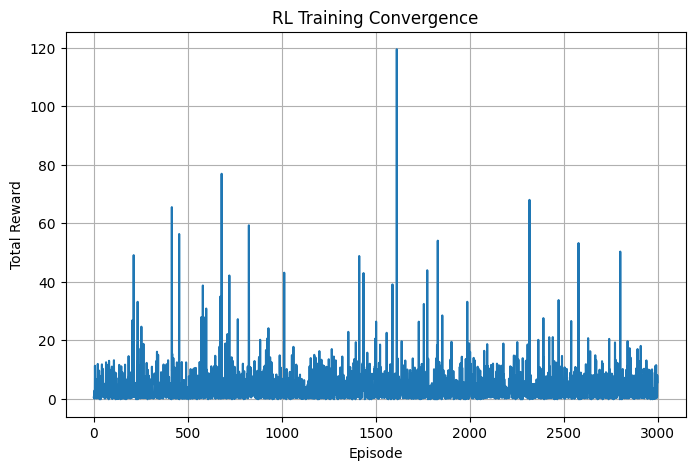

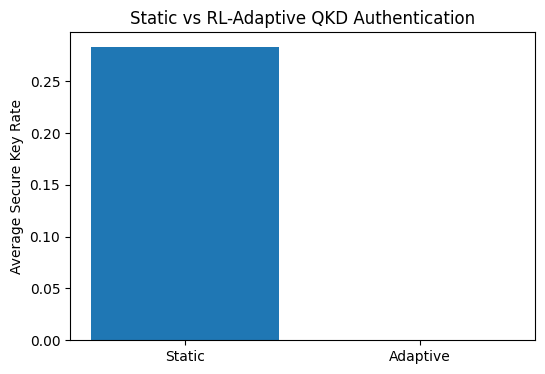

In [27]:
plt.figure(figsize=(8,5))
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("RL Training Convergence")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(["Static", "Adaptive"], [static_rate, adaptive_rate])
plt.ylabel("Average Secure Key Rate")
plt.title("Static vs RL-Adaptive QKD Authentication")
plt.show()


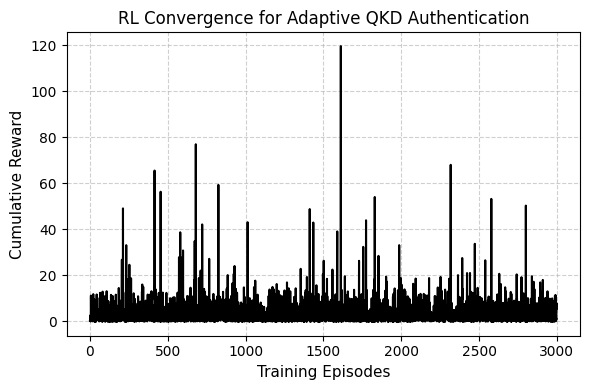

In [28]:
plt.figure(figsize=(6,4))
plt.plot(
    reward_history,
    linewidth=1.5,
    color="black"
)

plt.xlabel("Training Episodes", fontsize=11)
plt.ylabel("Cumulative Reward", fontsize=11)
plt.title("RL Convergence for Adaptive QKD Authentication", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


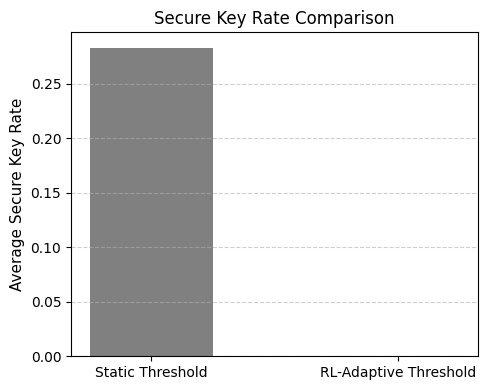

In [29]:
plt.figure(figsize=(5,4))

labels = ["Static Threshold", "RL-Adaptive Threshold"]
values = [static_rate, adaptive_rate]

plt.bar(
    labels,
    values,
    color=["gray", "black"],
    width=0.5
)

plt.ylabel("Average Secure Key Rate", fontsize=11)
plt.title("Secure Key Rate Comparison", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


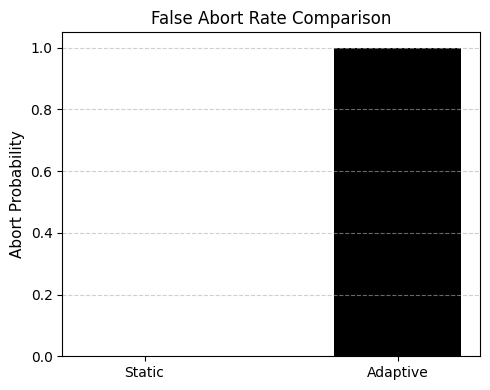

In [30]:
def abort_rate_static(threshold=0.11, runs=500):
    aborts = 0
    for _ in range(runs):
        stats = simulate_bb84_channel(
            channel_loss=random.uniform(0.05, 0.3),
            noise_level=random.uniform(0.005, 0.04),
            eavesdropper=random.random() < 0.3
        )
        if stats["QBER"] > threshold:
            aborts += 1
    return aborts / runs


def abort_rate_adaptive(runs=500):
    aborts = 0
    for _ in range(runs):
        state = env.reset()
        while True:
            action = agent.select_action(state)
            state, reward, done = env.step(action)
            if done:
                if reward <= 0:
                    aborts += 1
                break
    return aborts / runs


abort_static = abort_rate_static()
abort_adaptive = abort_rate_adaptive()

plt.figure(figsize=(5,4))
plt.bar(
    ["Static", "Adaptive"],
    [abort_static, abort_adaptive],
    color=["gray", "black"],
    width=0.5
)
plt.ylabel("Abort Probability", fontsize=11)
plt.title("False Abort Rate Comparison", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [31]:
def heuristic_adaptive(runs=500):
    total = 0
    for _ in range(runs):
        stats = simulate_bb84_channel(
            channel_loss=random.uniform(0.05, 0.3),
            noise_level=random.uniform(0.005, 0.04),
            eavesdropper=random.random() < 0.3
        )
        qber = stats["QBER"]

        # Simple heuristic
        threshold = 0.15 if qber < 0.08 else 0.10

        if qber <= threshold:
            total += secure_key_rate(qber)

    return total / runs


heuristic_rate = heuristic_adaptive()

print("Static Key Rate   :", static_rate)
print("Heuristic Key Rate:", heuristic_rate)
print("RL Key Rate       :", adaptive_rate)


Static Key Rate   : 0.2830174788722737
Heuristic Key Rate: 0.2806102778126733
RL Key Rate       : 0


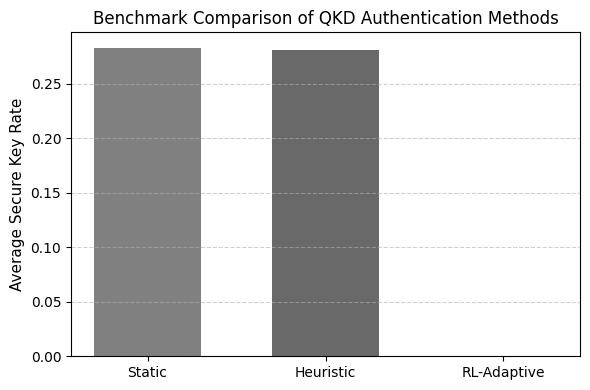

In [32]:
plt.figure(figsize=(6,4))

methods = ["Static", "Heuristic", "RL-Adaptive"]
rates = [static_rate, heuristic_rate, adaptive_rate]

plt.bar(
    methods,
    rates,
    color=["gray", "dimgray", "black"],
    width=0.6
)

plt.ylabel("Average Secure Key Rate", fontsize=11)
plt.title("Benchmark Comparison of QKD Authentication Methods", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
